# Análisis de viabilidad del TFM
En `df_fases_MES`tengo la **fase**, **máquina dominante**, y el **grupo/familia de esa máquina**. Con eso puedo montar un  cruce fase × máquina dentro de cada familia, ahi es donde vive la decisión de asignación.

Entonces, la elección real no es "esta fase fue a esta máquina" (eso siempre pasa). La elección existe cuando fases del mismo tipo pudieron ir a máquinas distintas de la misma familia.   
Por eso el análisis interesante es dentro de cada grupo: `¿las fases de una familia se reparten entre sus varias máquinas, o cada tipo de fase va siempre a la misma?`

In [161]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pyarrow as pa
import pickle
from scipy import stats

# Construir el ratio real/teórico:

In [162]:
df_final = pd.read_parquet("res//procesed/df_final.parquet")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)   
display(df_final.head(1))

,SmFaseUid,MaquinaDominante,fecha_fase,smOrdenId,smMaterialId,smFaseNme,smOrdenNme,MinutosReal_efectivo,MinutosPreparacion_efectivo,MinutosProduccion_efectivo,MinutosReal_total,MinutosPreparacion_total,MinutosProduccion_total,dedicacion_media,n_imputaciones,IDMaquina,NombreMaquina,IDGrupo,CodigoGrupo,NombreGrupo,IDMOTask,IDManufacturingOrder,Description,PreparationTime,ExecutionTime,TimeUnit,ProductEntry,MaterialExit,IDUsualTask,Quantity,ManualStartDate,RealEndDate,MESEntityId,Código Artículo,Descripción Artículo,CodProductLine,Nombre Línea,CodProductFamily,Nombre Família
0,00013c31-3895-4370-bb3e-4255371e8d8f,TN09,2025-10-02 03:12:05.010,OF2509545,PE1JNCX0012,TPP,Portacápsulas F704501049704(150713),41.76667,41.76667,0.0,41.76667,41.76667,0.0,50.0,2,0bab3b63-5d31-4de3-85e2-89dc5a3e9bd5,TPP DOOSAN PUMA 240 (TPP) Torn C.N.C,27451f15-090c-42a6-82d6-98b7451db3db,TPU,Torns Puma (Taller COURES),ee76d685-a4cc-47d4-b418-6e33d2ae2921,26a3fecc-120e-49bf-9e77-720d35355e3d,Mecanitzat al Torn Puma Petit,6.0,15.0,1.0,0.0,0.0,29783995-2f56-48be-9664-461e6f0b402a,3.0,2025-10-13 12:55:00.000,2025-10-02 00:00:00.000,00013c31-3895-4370-bb3e-4255371e8d8f,PE1JNCX0012,Elektrodenaufnamhe F704501049704(DS086228),P,Portalectrodes,PE,Portalectrodes


**Variables de tiempo**
- `MinutosRealNbr`, `MinutosPreparacionNbr`, `MinutosProduccionNbr`: dato original del MES, tiempo crudo (de reloj), sin corregir por dedicación. Vive a nivel de imputación individual.

- `MinutosReal_total`, `MinutosPreparacion_total`, `MinutosProduccion_total`: sumatorio del tiempo en crudo (de reloj) de todas las imputaciones de una misma fase.

- `MinutosReal_efectivo`, `MinutosPreparacion_efectivo`, `MinutosProduccion_efectivo`: Minutos reales totales de tiempo del MES corregido por el porcentaje de dedicación (`PorcentajeDedicacionNbr`) a nivel de imputación, y después sumado para todas las imputaciones de la fase.

MinutosReal_efectivo = MinutosRealNbr * PorcentajeDedicacionNbr / 100.

**Tiempos TEÓRICOS del ERP (lo que debería tardar):**     
- `PreparationTime` — teórico de preparación     
- `ExecutionTime` — teórico de ejecución/producción    

## Creación variable objetivo
La variable objetivo es el ratio entre el tiempo estimado (teórico) y el tiempo práctico (dedicado).

In [163]:
# --- Construcción del ratio sobre el tiempo EFECTIVO (teniendo en cuenta la dedicación) ---
df_final["tiempo_real_efectivo"] = df_final["MinutosReal_efectivo"]
df_final["tiempo_previsto"] = df_final["PreparationTime"] + df_final["ExecutionTime"]

df_final["ratio"] = df_final["tiempo_real_efectivo"] / df_final["tiempo_previsto"]

# --- Verificaciones ---
# ningún previsto en 0 (rompería la división)
print(f"Verificar Previsto = 0: {(df_final['tiempo_previsto'] == 0).sum()}")
# ninguna fase con tiempo real efectivo 0 (ratio = 0, sin señal)
print(f"Verificar  Real efectivo = 0 (ratio 0): {(df_final['tiempo_real_efectivo'] == 0).sum()}")

# distribución del ratio
print("\nDistribución del ratio (con tiempo efectivo):")
print(df_final["ratio"].describe())

display(df_final.sample(2))

Verificar Previsto = 0: 0
Verificar  Real efectivo = 0 (ratio 0): 0

Distribución del ratio (con tiempo efectivo):
count    14759.000000
mean         2.031888
std          2.538373
min          0.000114
25%          0.968617
50%          1.464444
75%          2.342942
max        150.616665
Name: ratio, dtype: float64


,SmFaseUid,MaquinaDominante,fecha_fase,smOrdenId,smMaterialId,smFaseNme,smOrdenNme,MinutosReal_efectivo,MinutosPreparacion_efectivo,MinutosProduccion_efectivo,MinutosReal_total,MinutosPreparacion_total,MinutosProduccion_total,dedicacion_media,n_imputaciones,IDMaquina,NombreMaquina,IDGrupo,CodigoGrupo,NombreGrupo,IDMOTask,IDManufacturingOrder,Description,PreparationTime,ExecutionTime,TimeUnit,ProductEntry,MaterialExit,IDUsualTask,Quantity,ManualStartDate,RealEndDate,MESEntityId,Código Artículo,Descripción Artículo,CodProductLine,Nombre Línea,CodProductFamily,Nombre Família,tiempo_real_efectivo,tiempo_previsto,ratio
4721,528ea6b3-2c5f-4549-a3eb-0e4f0224db44,TP02,2025-10-31 17:37:02.317,OF2510946,PE7XA3X0008,MTP,Electrode holder WH22549,48.51667,48.51667,0.0,48.51667,48.51667,0.0,50.0,2,a045db52-b7d0-4011-b402-e7f63d5e4d3a,MTP IMSA MF800C-HD Màquina Taladres Profunds,7d29197b-e1a1-4c19-bf95-7fa3b96ed500,MTP,Màquines de Taladrat Profund,5fbf0cd3-d420-4a63-8fcb-9736e4c433a4,51858a79-46f1-4c86-beed-fa4e8ec6cd5f,Màquina de taladrat profund,5.0,12.0,1.0,0.0,0.0,4cfbb761-89c5-49c3-b68a-4a4024d85c8f,2.0,2025-10-16 08:25:00.000,2025-10-31 00:00:00.000,528ea6b3-2c5f-4549-a3eb-0e4f0224db44,PE7XA3X0008,Electrode holder WH22549,P,Portalectrodes,PE,Portalectrodes,48.51667,17.0,2.853922
5968,681b1cb9-d148-4843-a18e-36b3f6f27222,TN08,2025-12-04 06:11:43.313,OF2511849,PE0XA2T0001,TPP,Elektrodenaufnahme F704500536740,134.85000,122.55000,12.3,134.85000,122.55000,12.3,50.0,2,bf44bec2-aa1e-4002-8da5-922a1001645d,HYUNDAI-KIA TURN H15 Torn C.N.C,6977175d-a2da-4925-a70f-fd0fcc4a2960,TCN,Torns Control Numèric,9760b94e-3562-46f8-a807-83439bf28091,d389a8f2-6d8b-42f3-bfd1-39736540ae14,Mecanitzat al Torn Puma Petit,5.0,50.0,1.0,0.0,0.0,29783995-2f56-48be-9664-461e6f0b402a,10.0,2025-12-12 13:17:00.000,2025-12-04 00:00:00.000,681b1cb9-d148-4843-a18e-36b3f6f27222,PE0XA2T0001,Elektrodenaufnahme F704500536740,P,Portalectrodes,PE,Portalectrodes,134.85000,55.0,2.451818


Los 54 con ratio = 0 (real efectivo nulo). Estas fases tienen teórico pero su tiempo real efectivo es 0 — probablemente fases cuyas imputaciones tenían todas dedicación 0, o tiempo real 0. Un ratio de 0 no significa "idoneidad perfecta", significa "sin dato de tiempo real". Hay que descartarlas, mismo argumento que los teóricos 0: sin real medible, no hay idoneidad.

In [164]:
antes = len(df_final)
df_final = df_final[df_final["tiempo_real_efectivo"] > 0]
print(f"Descartadas (ratio 0): {antes - len(df_final)}")
print(f"Total imputaciones: {len(df_final)}")

Descartadas (ratio 0): 0
Total imputaciones: 14759


El máximo de 150.61 es demasiado alto, físicamente es imposible como "mala idoneidad" real. Es ruido residual (solapamiento que la dedicación no capturó del todo, teóricos minúsculos mal cargados, o algún caso raro). 

In [165]:
# --- Exploración de ambas colas antes de cortar ---

# cola alta: cuántas fases con distintos umbrales
print("=== COLA ALTA (tardó mucho más que el teórico) ===")
for umbral in [5, 8, 10, 15, 20]:
    n = (df_final["ratio"] >= umbral).sum()
    print(f"  Ratio >= {umbral:>2}: {n:>4} fases ({n/len(df_final):.1%})")

# cola baja: cuántas fases sospechosamente rápidas
print("\n=== COLA BAJA (tardó mucho menos que el teórico) ===")
for umbral in [0.5, 0.3, 0.2, 0.1]:
    n = (df_final["ratio"] <= umbral).sum()
    print(f"  Ratio <= {umbral}: {n:>4} fases ({n/len(df_final):.1%})")

# percentiles para calibrar el corte con criterio estadístico
print("\n=== PERCENTILES ===")
for p in [0.01, 0.02, 0.05, 0.95, 0.98, 0.99]:
    print(f"  P{int(p*100):>2}: {df_final['ratio'].quantile(p):.3f}")

=== COLA ALTA (tardó mucho más que el teórico) ===
  Ratio >=  5:  800 fases (5.4%)
  Ratio >=  8:  261 fases (1.8%)
  Ratio >= 10:  154 fases (1.0%)
  Ratio >= 15:   64 fases (0.4%)
  Ratio >= 20:   32 fases (0.2%)

=== COLA BAJA (tardó mucho menos que el teórico) ===
  Ratio <= 0.5:  885 fases (6.0%)
  Ratio <= 0.3:  404 fases (2.7%)
  Ratio <= 0.2:  260 fases (1.8%)
  Ratio <= 0.1:  158 fases (1.1%)

=== PERCENTILES ===
  P 1: 0.092
  P 2: 0.229
  P 5: 0.448
  P95: 5.199
  P98: 7.521
  P99: 10.274


Como digo Outliers que son ruido (MES abierto, errores de registro, teóricos mal cargados) → hay que eliminarlos, contaminan el aprendizaje.

Dado que el ratio es una magnitud multiplicativa —expresa cuántas veces el tiempo real excede o queda por debajo del teórico—, el corte de valores atípicos se aplica sobre su logaritmo, donde la distribución resulta simétrica en torno a 0. Sobre log(ratio) se calcula el rango intercuartílico (IQR) y se definen como atípicos los valores fuera de [Q1 − 1,5·IQR, Q3 + 1,5·IQR]. Deshaciendo la transformación logarítmica, esto define un intervalo de valores admisibles de aproximadamente [0,26, 8,82].

In [166]:
log_ratio = np.log(df_final["ratio"])
q1, q3 = log_ratio.quantile([0.25, 0.75])
iqr = q3 - q1 
UMBRAL_BAJO = np.exp(q1 - 1.5 * iqr).round(3)
UMBRAL_ALTO = np.exp(q3 + 1.5 * iqr).round(3)

print(f"Umbrales: {UMBRAL_BAJO} (bajo) - {UMBRAL_ALTO} (alto)")

Umbrales: 0.257 (bajo) - 8.814 (alto)


In [167]:
antes = len(df_final)
alta = (df_final["ratio"] >= UMBRAL_ALTO).sum()
baja = (df_final["ratio"] <= UMBRAL_BAJO).sum()

df_final2 = df_final[(df_final["ratio"] > UMBRAL_BAJO) & (df_final["ratio"] < UMBRAL_ALTO)]

print(f"Descartadas cola alta (>= {UMBRAL_ALTO}): {alta}")
print(f"Descartadas cola baja (<= {UMBRAL_BAJO}): {baja}")
print(f"Total: {antes} → {len(df_final2)}")

Descartadas cola alta (>= 8.814): 205
Descartadas cola baja (<= 0.257): 331
Total: 14759 → 14223


> Los cortes son asimétricos en interpretación, aunque parezcan simétricos en número. 
- El de arriba (≥9) quita "tardó absurdamente mucho", casi seguro tiempo muerto. 
- El de abajo (≤0.2) quita "tardó absurdamente poco", casi seguro teórico mal cargado o real incompleto. 
>Son dos problemas de datos distintos que dan la misma señal (ratio implausible), y ambos justifican el descarte.

In [168]:
print("Distribución del ratio:")
print(df_final2["ratio"].describe())

Distribución del ratio:
count    14223.000000
mean         1.886212
std          1.360957
min          0.257485
25%          0.998204
50%          1.474667
75%          2.317495
max          8.800000
Name: ratio, dtype: float64


Graficar la necesidad de emplear un umbral para los ratios

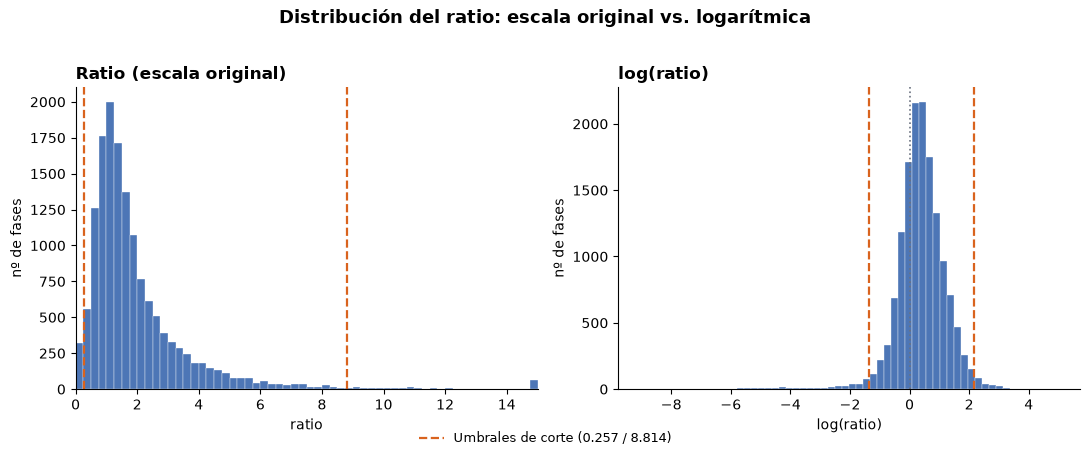

In [169]:
# ratio vs. log(ratio)
from matplotlib.lines import Line2D

log_ratio = np.log(df_final["ratio"])
log_bajo = np.log(UMBRAL_BAJO)
log_alto = np.log(UMBRAL_ALTO)

BLUE, ORANGE, GRAY = '#2E5EAA', '#D9631E', '#6B7280'

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

ax = axes[0]
ax.hist(df_final["ratio"].clip(upper=15), bins=60, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(UMBRAL_BAJO, color=ORANGE, linewidth=1.6, linestyle='--')
ax.axvline(UMBRAL_ALTO, color=ORANGE, linewidth=1.6, linestyle='--')
ax.set_title('Ratio (escala original)', fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('ratio'); ax.set_ylabel('nº de fases')
ax.set_xlim(0, 15)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax2 = axes[1]
ax2.hist(log_ratio, bins=60, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.3)
ax2.axvline(0, color=GRAY, linewidth=1.2, linestyle=':')
ax2.axvline(log_bajo, color=ORANGE, linewidth=1.6, linestyle='--')
ax2.axvline(log_alto, color=ORANGE, linewidth=1.6, linestyle='--')
ax2.set_title('log(ratio)', fontsize=12, fontweight='bold', loc='left')
ax2.set_xlabel('log(ratio)'); ax2.set_ylabel('nº de fases')
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

fig.legend(handles=[Line2D([0], [0], color=ORANGE, lw=1.6, linestyle='--',
           label=f'Umbrales de corte ({UMBRAL_BAJO} / {UMBRAL_ALTO})')],
           loc='lower center', frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=9)

fig.suptitle('Distribución del ratio: escala original vs. logarítmica', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("res/procesed/graficos/03_ratio_vs_log_ratio.png", dpi=200, bbox_inches='tight')
plt.show()

#### Estudiar los outliers de la cola baja:

In [191]:
# Justificación de la cola baja: outliers con patrón de registro incompleto en MES
outliers_bajo = df_final[df_final["ratio"] < UMBRAL_BAJO]
n_imputaciones_minimas = outliers_bajo[outliers_bajo["n_imputaciones"] == 2].copy()

n_total = len(outliers_bajo)
n_minimas = len(n_imputaciones_minimas)

# --- Patrón de imputaciones ---
print(f"Outliers cola baja: {n_total}")
print(f"Con n_imputaciones == 2: {n_minimas} ({100*n_minimas/n_total:.1f}%)")
print()
print("Tiempo real efectivo (min) en ese subgrupo:")
print(n_imputaciones_minimas["tiempo_real_efectivo"].describe())
print()
print("Mediana dedicación media:", n_imputaciones_minimas["dedicacion_media"].median())
print("Nº medio de imputaciones en fases no-outlier:",
      df_final.loc[~df_final.index.isin(outliers_bajo.index), "n_imputaciones"].mean().round(2))

# --- Distribución temporal ---
print("\n" + "="*50)
print("Rango temporal del dataset:", df_final["fecha_fase"].min(), "->", df_final["fecha_fase"].max())
print("Rango temporal de estos outliers:", n_imputaciones_minimas["fecha_fase"].min(), "->", n_imputaciones_minimas["fecha_fase"].max())

outlier_mes = n_imputaciones_minimas["fecha_fase"].dt.to_period("M").value_counts().sort_index()
total_mes = df_final["fecha_fase"].dt.to_period("M").value_counts().sort_index()
tasa_mensual = (outlier_mes / total_mes * 100).round(2)

print("\nTasa mensual (%):")
print(tasa_mensual)
print(f"Media: {tasa_mensual.mean():.2f}%   Desv. estándar: {tasa_mensual.std():.2f}")

# --- Concentración por máquina ---
print("\n" + "="*50)
print("Por máquina:")
print(n_imputaciones_minimas["MaquinaDominante"].value_counts().to_string())

# --- Concentración por artículo ---
n_imputaciones_minimas["Nombre Línea"] = n_imputaciones_minimas["Nombre Línea"].fillna("(sin línea)")
n_imputaciones_minimas["Nombre Família"] = n_imputaciones_minimas["Nombre Família"].fillna("(sin família)")

print("\n" + "="*50)
print("Por línea de artículo:")
print(n_imputaciones_minimas["Nombre Línea"].value_counts().to_string())
print("\nPor família de artículo:")
print(n_imputaciones_minimas["Nombre Família"].value_counts().to_string())

Outliers cola baja: 331
Con n_imputaciones == 2: 282 (85.2%)

Tiempo real efectivo (min) en ese subgrupo:
count    282.000000
mean      16.730064
std       32.063034
min        0.027848
25%        0.450394
50%        3.950223
75%       17.178128
max      239.366670
Name: tiempo_real_efectivo, dtype: float64

Mediana dedicación media: 50.0
Nº medio de imputaciones en fases no-outlier: 2.52

Rango temporal del dataset: 2025-06-02 14:01:02.623000 -> 2026-07-31 17:14:04.953000
Rango temporal de estos outliers: 2025-06-10 13:15:13.793000 -> 2026-07-31 17:14:04.953000

Tasa mensual (%):
fecha_fase
2025-06    1.32
2025-07    3.06
2025-08    1.74
2025-09    1.58
2025-10    2.35
2025-11    1.90
2025-12    1.36
2026-01    1.26
2026-02    1.17
2026-03    2.63
2026-04    2.31
2026-05    2.23
2026-06    1.28
2026-07    1.57
Freq: M, Name: count, dtype: float64
Media: 1.84%   Desv. estándar: 0.59

Por máquina:
MaquinaDominante
TP02    69
PH04    40
CM14    20
CM05    20
TN05    17
TP01    17
TN09   

Estos errores se manteiene a lo largo del año y de forma equitateva entre la mayoria de las maquians, por la forma en que se dan esto apunta a ser ruido sistematico. Hay fases que no se contemplan a la hora de imputar tiempos, y los operarios las abren para marcar la cantidad producida y después las cierran, sin tener en cuenta el registro de tiempo. Por eso son registros tan bajos, deben eliminarse.

#### Inspeccionar la cola alta ahora 

In [192]:
# Misma exploración para la cola alta (ratio anómalamente alto)
outliers_alto = df_final[df_final["ratio"] > UMBRAL_ALTO]
n_imputaciones_minimas = outliers_alto[outliers_alto["n_imputaciones"] == 2].copy()

n_total = len(outliers_alto)
n_minimas = len(n_imputaciones_minimas)

# --- Patrón de imputaciones ---
print(f"Outliers cola alta: {n_total}")
print(f"Con n_imputaciones == 2: {n_minimas} ({100*n_minimas/n_total:.1f}%)")
print()
print("Tiempo real efectivo (min) en ese subgrupo:")
print(n_imputaciones_minimas["tiempo_real_efectivo"].describe())
print()
print("Mediana dedicación media:", n_imputaciones_minimas["dedicacion_media"].median())
print("Nº medio de imputaciones en fases no-outlier:",
      df_final.loc[~df_final.index.isin(outliers_alto.index), "n_imputaciones"].mean().round(2))

# --- Distribución temporal ---
print("\n" + "="*50)
print("Rango temporal del dataset:", df_final["fecha_fase"].min(), "->", df_final["fecha_fase"].max())
print("Rango temporal de estos outliers:", n_imputaciones_minimas["fecha_fase"].min(), "->", n_imputaciones_minimas["fecha_fase"].max())

outlier_mes = n_imputaciones_minimas["fecha_fase"].dt.to_period("M").value_counts().sort_index()
total_mes = df_final["fecha_fase"].dt.to_period("M").value_counts().sort_index()
tasa_mensual = (outlier_mes / total_mes * 100).round(2)

print("\nTasa mensual (%):")
print(tasa_mensual)
print(f"Media: {tasa_mensual.mean():.2f}%   Desv. estándar: {tasa_mensual.std():.2f}")

# --- Concentración por máquina ---
print("\n" + "="*50)
print("Por máquina:")
print(n_imputaciones_minimas["MaquinaDominante"].value_counts().to_string())

# --- Concentración por artículo ---
n_imputaciones_minimas["Nombre Línea"] = n_imputaciones_minimas["Nombre Línea"].fillna("(sin línea)")
n_imputaciones_minimas["Nombre Família"] = n_imputaciones_minimas["Nombre Família"].fillna("(sin família)")

print("\n" + "="*50)
print("Por línea de artículo:")
print(n_imputaciones_minimas["Nombre Línea"].value_counts().to_string())
print("\nPor família de artículo:")
print(n_imputaciones_minimas["Nombre Família"].value_counts().to_string())

Outliers cola alta: 205
Con n_imputaciones == 2: 118 (57.6%)

Tiempo real efectivo (min) en ese subgrupo:
count    118.000000
mean     173.677785
std       88.953875
min       49.500000
25%      112.041670
50%      146.363164
75%      212.670835
max      465.083340
Name: tiempo_real_efectivo, dtype: float64

Mediana dedicación media: 50.0
Nº medio de imputaciones en fases no-outlier: 2.51

Rango temporal del dataset: 2025-06-02 14:01:02.623000 -> 2026-07-31 17:14:04.953000
Rango temporal de estos outliers: 2025-06-05 16:52:21.583000 -> 2026-07-31 15:31:55.547000

Tasa mensual (%):
fecha_fase
2025-06    1.76
2025-07    1.20
2025-08    0.82
2025-09    0.55
2025-10    0.81
2025-11    0.83
2025-12    1.15
2026-01    0.87
2026-02    0.29
2026-03    0.71
2026-04    0.58
2026-05    0.70
2026-06    0.21
2026-07    0.78
Freq: M, Name: count, dtype: float64
Media: 0.80%   Desv. estándar: 0.39

Por máquina:
MaquinaDominante
TP02    54
TN09    35
TP01    14
CM06     6
CM16     3
TN08     2
CM12   

Claramente se detecta unas maquinas y articulos predominantes, vamos analizarlos.

In [194]:
combo = df_final[
    (df_final["MaquinaDominante"].isin(["TP02", "TN09"])) &
    (df_final["Nombre Línea"] == "Portalectrodes")
]
resto = df_final[~(
    (df_final["MaquinaDominante"].isin(["TP02", "TN09"])) &
    (df_final["Nombre Línea"] == "Portalectrodes")
)]

print(f"Total fases combo TP02/TN09 + Portalectrodes: {len(combo)}")
print()
print("Estadísticos de ratio por máquina (dentro del combo):")
print(combo.groupby("MaquinaDominante")["ratio"].describe())
print()
print(f"Ratio mediano combo: {combo['ratio'].median():.3f}   vs. resto del dataset: {resto['ratio'].median():.3f}")
print(f"% de fases que superan UMBRAL_ALTO en el combo: {100*(combo['ratio']>UMBRAL_ALTO).mean():.2f}%")
print(f"% de fases que superan UMBRAL_ALTO en el resto: {100*(resto['ratio']>UMBRAL_ALTO).mean():.2f}%")

Total fases combo TP02/TN09 + Portalectrodes: 5297

Estadísticos de ratio por máquina (dentro del combo):
                   count      mean       std       min      25%       50%  \
MaquinaDominante                                                            
TN09              3123.0  2.543579  2.565470  0.003082  1.20631  1.878261   
TP02              2174.0  2.658356  3.207342  0.008424  1.13537  1.773070   

                       75%        max  
MaquinaDominante                       
TN09              3.080079  67.988096  
TP02              3.103201  72.339998  

Ratio mediano combo: 1.833   vs. resto del dataset: 1.313
% de fases que superan UMBRAL_ALTO en el combo: 2.59%
% de fases que superan UMBRAL_ALTO en el resto: 0.72%


##### Conclusión de las colas:
Los valores de ratio anómalamente bajos coinciden mayoritariamente con fases registradas con el número mínimo de imputaciones (2, frente a las 5-6 habituales) y un tiempo real registrado muy reducido — un patrón compatible con un registro administrativo incompleto más que con producción real anormalmente rápida. Se mantiene estable durante todo el periodo del dataset, sin picos ni tendencia, y se concentra de forma desigual por máquina (PH04, 22,86% de sus fases, frente al 1-7% del resto) y por artículo (Portalectrodes y Braços acumulan más del 60% de los casos). Comentando esta casuística con el personal de la planta de producción confirman el hallazgo.
En la cola alta la concentración es aún más extrema: 2 máquinas (TP02 y TN09) explican el 72,7% de los casos y una única línea de artículos, Portalectrodes, el 87,8%. Una dispersión mucho mayor que en la cola baja. Esto no encaja con ruido disperso, sino con una combinación máquina-artículo estructuralmente más lenta: sus fases no-outlier ya presentan un ratio mediano superior al resto del dataset (1,83 frente a 1,31). Aun así, dentro de esa misma combinación el percentil 75 del ratio se sitúa en torno a 3 (lejos del umbral de 8) y solo el 2,59% de sus fases lo superan, por lo que el corte no elimina esa tendencia real —que queda representada en el grueso de casos retenidos— sino sólo su extremo minoritario y atípico incluso dentro de su propio proceso. Se mantiene, por tanto, el mismo criterio de corte para la cola alta.


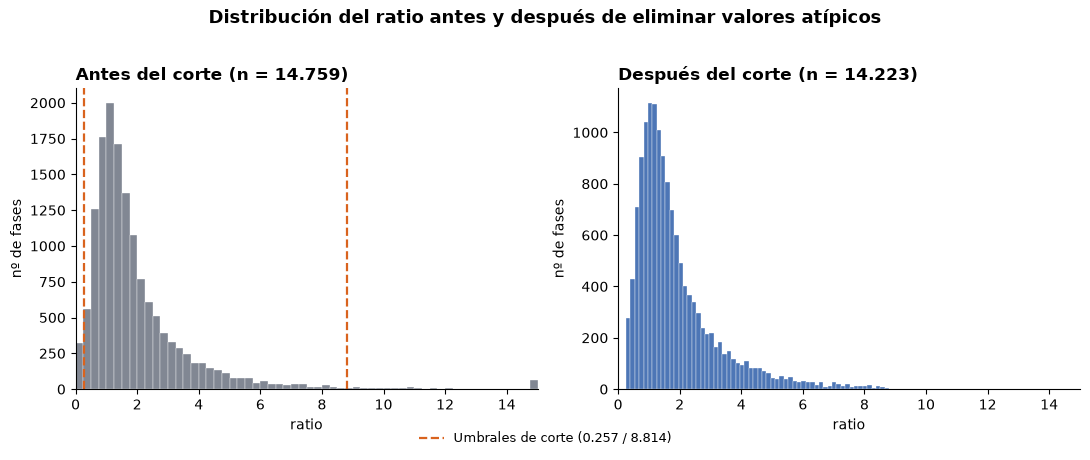

In [171]:
antes = df_final["ratio"]
despues = antes[(antes > UMBRAL_BAJO) & (antes < UMBRAL_ALTO)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))

ax = axes[0]
ax.hist(antes.clip(upper=15), bins=60, color=GRAY, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.axvline(UMBRAL_BAJO, color=ORANGE, linewidth=1.6, linestyle='--')
ax.axvline(UMBRAL_ALTO, color=ORANGE, linewidth=1.6, linestyle='--')
ax.set_title(f'Antes del corte (n = {len(antes):,})'.replace(',', '.'), fontsize=12, fontweight='bold', loc='left')
ax.set_xlabel('ratio'); ax.set_ylabel('nº de fases')
ax.set_xlim(0, 15)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax2 = axes[1]
ax2.hist(despues, bins=60, color=BLUE, alpha=0.85, edgecolor='white', linewidth=0.3)
ax2.set_title(f'Después del corte (n = {len(despues):,})'.replace(',', '.'), fontsize=12, fontweight='bold', loc='left')
ax2.set_xlabel('ratio'); ax2.set_ylabel('nº de fases')
ax2.set_xlim(0, 15)

for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

fig.legend(handles=[Line2D([0], [0], color=ORANGE, lw=1.6, linestyle='--',
           label=f'Umbrales de corte ({UMBRAL_BAJO} / {UMBRAL_ALTO})')],
           loc='lower center', frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=9)

fig.suptitle('Distribución del ratio antes y después de eliminar valores atípicos', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("res/procesed/graficos/05_antes_despues_corte.png", dpi=200, bbox_inches='tight')
plt.show()

In [196]:
display(df_final2.shape)

(14223, 42)

In [197]:
df_entrenamiento = df_final2.drop(columns=["MinutosPreparacion_efectivo", # columnas de datos
                                               "MinutosProduccion_efectivo", 
                                               "MinutosReal_efectivo", 
                                               "MinutosReal_total", 
                                               "MinutosPreparacion_total", 
                                               "MinutosProduccion_total", 
                                               "dedicacion_media", 
                                               "n_imputaciones", 
                                               "TimeUnit", 
                                               "ManualStartDate",  
                                               "RealEndDate", 
                                               "PreparationTime", 
                                               "ExecutionTime"])

df_entrenamiento = df_entrenamiento.drop(columns=["IDMaquina", # columnas de identificación
                                                "IDGrupo",
                                                "IDManufacturingOrder",
                                                "MESEntityId",
                                                "SmFaseUid"])

display(df_entrenamiento.sample(1))

,MaquinaDominante,fecha_fase,smOrdenId,smMaterialId,smFaseNme,smOrdenNme,NombreMaquina,CodigoGrupo,NombreGrupo,IDMOTask,Description,ProductEntry,MaterialExit,IDUsualTask,Quantity,Código Artículo,Descripción Artículo,CodProductLine,Nombre Línea,CodProductFamily,Nombre Família,tiempo_real_efectivo,tiempo_previsto,ratio
4029,TP02,2025-08-12 15:27:15.847,OF2508317,PE1XA2X0165,MTP,Allonge coudée 062ZF20016423ZR,MTP IMSA MF800C-HD Màquina Taladres Profunds,MTP,Màquines de Taladrat Profund,9d7ea9d8-51d2-4813-8f92-523bdb737aed,Màquina de taladrat profund,0.0,0.0,4cfbb761-89c5-49c3-b68a-4a4024d85c8f,2.0,PE1XA2X0165,Allonge coudée 062ZF20016423ZR,P,Portalectrodes,PE,Portalectrodes,3.6,13.0,0.276923


In [198]:
# reordenar columnas
df_entrenamiento = df_entrenamiento[["fecha_fase",
                                     "IDMOTask",
                                     "smOrdenId", 
                                     "smOrdenNme",
                                     "smFaseNme",
                                     "Description",
                                     "IDUsualTask",
                                     "MaquinaDominante", 
                                     "NombreMaquina", 
                                     "CodigoGrupo", 
                                     "NombreGrupo",
                                     "smMaterialId",
                                     "Descripción Artículo", 
                                     "CodProductLine",
                                     "Nombre Línea",
                                     "CodProductFamily",
                                     "Nombre Família",
                                     "ProductEntry", 
                                     "MaterialExit",  
                                     "Quantity", 
                                     "tiempo_real_efectivo", 
                                     "tiempo_previsto", 
                                     "ratio"]]

display(df_entrenamiento.sample(1))

,fecha_fase,IDMOTask,smOrdenId,smOrdenNme,smFaseNme,Description,IDUsualTask,MaquinaDominante,NombreMaquina,CodigoGrupo,NombreGrupo,smMaterialId,Descripción Artículo,CodProductLine,Nombre Línea,CodProductFamily,Nombre Família,ProductEntry,MaterialExit,Quantity,tiempo_real_efectivo,tiempo_previsto,ratio
9248,2026-03-02 15:31:31.010,d96b5d99-3ea1-4f57-89c8-87e64b031e97,OF2601239,Elektrodenarm Ø60 F2668260003763611,TPG-CNY,Mecanitzar Canya al TPU,2562d1e9-8157-4c9e-aff1-b77b7a7e2868,TN04,TPG DAEWOO PUMA 400L (TPG) Torn C.N.C,TPU,Torns Puma (Taller COURES),BR2XA2X0213,Elektrodenarm Ø60 F2668260003763611,B,Braços,BR,Braços rodons,0.0,0.0,4.0,225.71666,142.0,1.589554


Cambiar nombres de las máquinas.

In [199]:
print(set(df_entrenamiento['NombreGrupo']))

{'Màquines Secció Flexibles', 'Centres de Mecanitzat Vertical ALUMINIS', 'Centres de Mecanitzat Horitzontal COURES', 'Torns Puma (Taller COURES)', 'Torns Control Numèric', 'Premses Conformats', 'Màquines de Taladrat Profund', 'Centres de Mecanitzat Vertical COURES', 'Centre de Mecanitzat 5 Eixos petites'}


In [200]:
mapeo_nombres = {
    "Centres de Mecanitzat Vertical ALUMINIS": "Centros Mecanizado Vertical Aluminio",
    "Premses Conformats": "Premsas Conformados",
    "Centres de Mecanitzat Horitzontal COURES": "Centros Mecanizado Horizontal Cobre",
    "Centres de Mecanitzat Vertical COURES": "Centros Mecanizado Vertical Cobre",
    "Torns Control Numèric": "Tornos Control Numérico",
    "Màquines de Taladrat Profund": "Maquinas de Taladrado",
    "Centre de Mecanitzat 5 Eixos petites": "Centros de Mecanizado 5 Ejes",
    "Màquines Secció Flexibles": "Máquinas Sección Flexible",
    "Torns Puma (Taller COURES)": "Tornos Puma Cobre",
}

df_entrenamiento["NombreGrupo"] = df_entrenamiento["NombreGrupo"].replace(mapeo_nombres)

Ratio por máquinas:

RATIO POR FAMILIA DE MÁQUINA
                                         n  media  mediana  desv_est
NombreGrupo                                                         
Maquinas de Taladrado                 3409  2.132    1.618     1.529
Tornos Puma Cobre                     4004  2.122    1.666     1.486
Centros Mecanizado Vertical Cobre     2582  1.868    1.499     1.255
Centros de Mecanizado 5 Ejes           524  1.715    1.440     1.260
Premsas Conformados                    247  1.649    1.262     1.369
Tornos Control Numérico               1594  1.489    1.213     1.016
Máquinas Sección Flexible              171  1.431    1.318     0.688
Centros Mecanizado Horizontal Cobre   1204  1.411    1.205     0.815
Centros Mecanizado Vertical Aluminio   488  1.267    0.958     0.971


C:\Users\jaume\AppData\Local\Temp\ipykernel_272\2804826504.py:14: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True, showfliers=False)


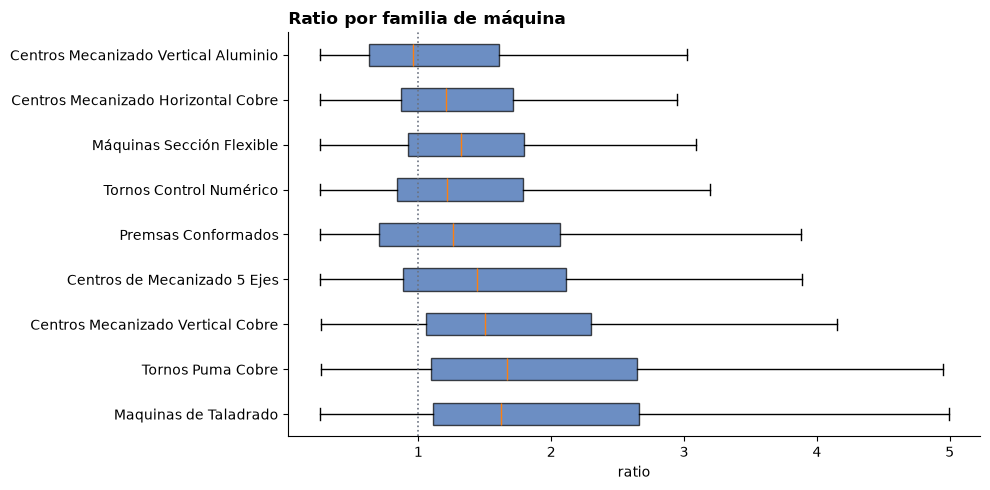

In [201]:
stats_familia = df_entrenamiento.groupby("NombreGrupo")["ratio"].agg(
    n="count", media="mean", mediana="median", desv_est="std"
).sort_values("media", ascending=False)

print("=" * 70)
print("RATIO POR FAMILIA DE MÁQUINA")
print("=" * 70)
print(stats_familia.round(3))

orden = stats_familia.index.tolist()
data = [df_entrenamiento.loc[df_entrenamiento["NombreGrupo"] == f, "ratio"] for f in orden]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data, vert=False, patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor(BLUE); patch.set_alpha(0.7)
ax.set_yticklabels(orden)
ax.axvline(1, color=GRAY, linestyle=':', linewidth=1.2)
ax.set_xlabel("ratio")
ax.set_title("Ratio por familia de máquina", fontsize=12, fontweight='bold', loc='left')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("res/procesed/graficos/ratio_por_familia.png", dpi=200, bbox_inches='tight')
plt.show()

Revisar los ratios por familias de maquinas

RATIO POR FAMÍLIA DE ARTÍCULO
                                            n  media  mediana  desv_est
Nombre Família                                                         
Producte Línia Centres                      2  4.572    4.572     4.214
Brida                                       8  2.887    2.023     2.898
Cala                                        2  2.553    2.553     1.813
Tub Refrigeració                            2  2.546    2.546     2.026
Reparacions                                 5  2.537    1.758     2.810
Suport                                      7  2.533    1.750     2.600
Portalectrodes                           7959  2.161    1.701     1.493
Placa Protecció/Aïllant/Xapeta              4  2.032    1.488     1.127
Electrode Doblegat                          4  2.002    1.375     1.471
Eix                                        40  1.998    1.743     1.331
Roldana                                    16  1.973    1.205     1.688
Terminal                          

C:\Users\jaume\AppData\Local\Temp\ipykernel_272\525581638.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data, vert=False, patch_artist=True, showfliers=False)


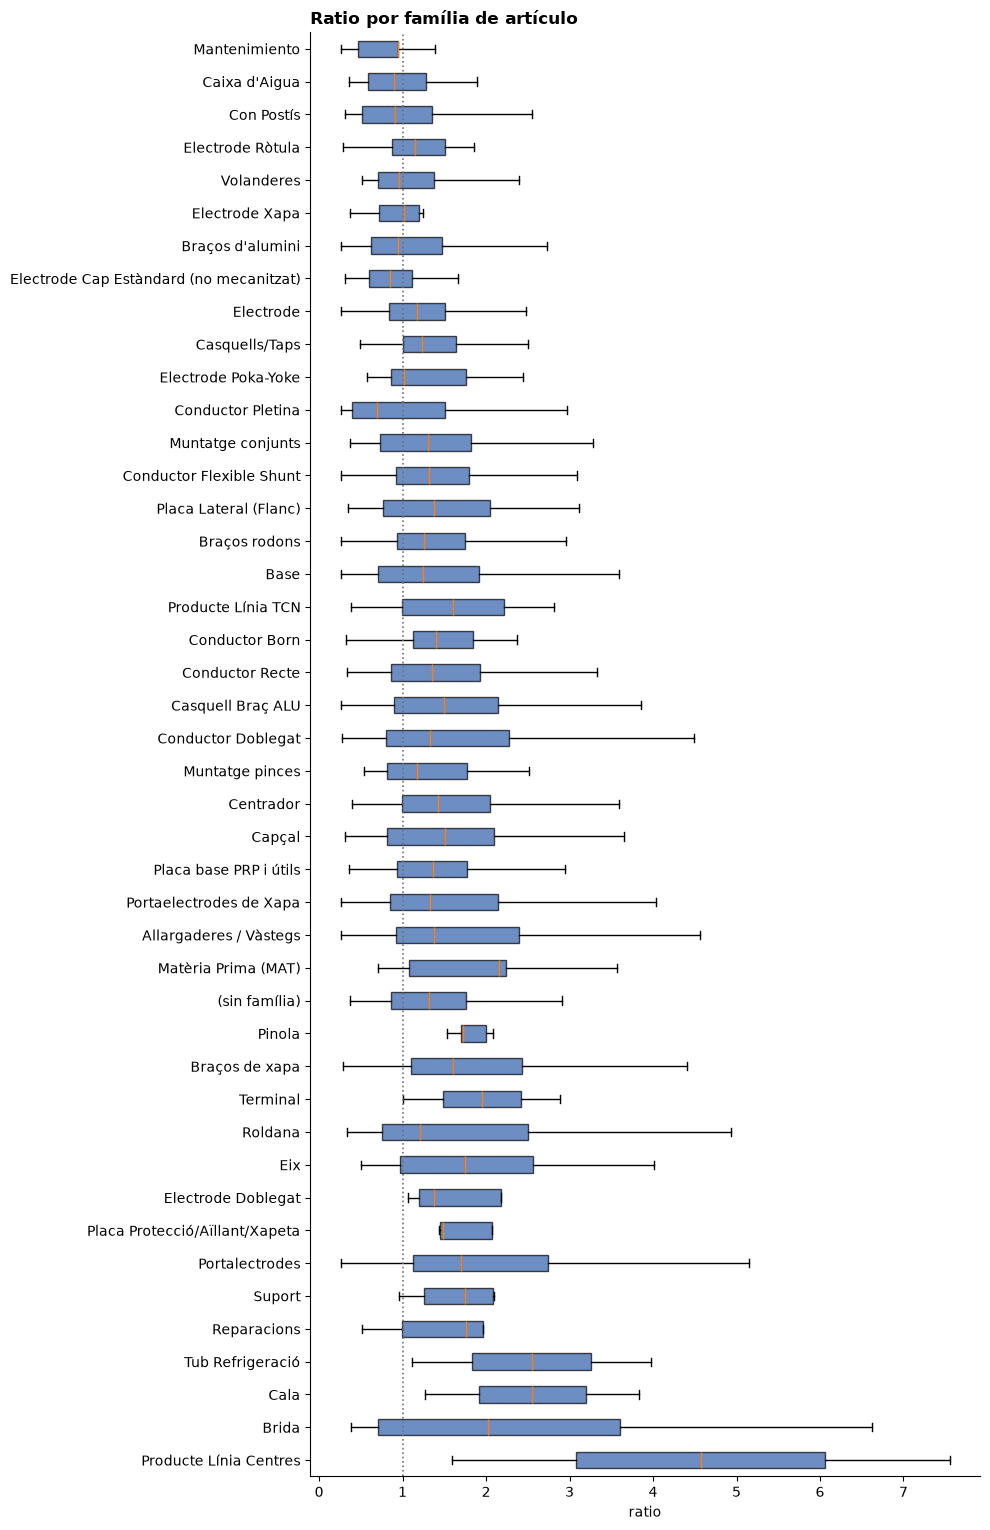

In [202]:
df_entrenamiento["Nombre Família"] = df_entrenamiento["Nombre Família"].fillna("(sin família)")

conteo_familia_art = df_entrenamiento["Nombre Família"].value_counts()
familias_validas = conteo_familia_art.index

stats_familia_art = df_entrenamiento[df_entrenamiento["Nombre Família"].isin(familias_validas)] \
    .groupby("Nombre Família")["ratio"].agg(
        n="count", media="mean", mediana="median", desv_est="std"
    ).sort_values("media", ascending=False)

print("=" * 70)
print(f"RATIO POR FAMÍLIA DE ARTÍCULO")
print("=" * 70)
print(stats_familia_art.round(3))

orden = stats_familia_art.index.tolist()
data = [df_entrenamiento.loc[df_entrenamiento["Nombre Família"] == f, "ratio"] for f in orden]

fig, ax = plt.subplots(figsize=(10, max(5, len(orden) * 0.35)))
bp = ax.boxplot(data, vert=False, patch_artist=True, showfliers=False)
for patch in bp['boxes']:
    patch.set_facecolor(BLUE); patch.set_alpha(0.7)
ax.set_yticklabels(orden)
ax.axvline(1, color=GRAY, linestyle=':', linewidth=1.2)
ax.set_xlabel("ratio")
ax.set_title("Ratio por família de artículo", fontsize=12, fontweight='bold', loc='left')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("res/procesed/graficos/ratio_por_familia_articulo.png", dpi=200, bbox_inches='tight')
plt.show()

Investigar en base las cantidades por fabricación:

RATIO vs CANTIDAD (tamaño de lote)
Correlación de Pearson:  r = -0.0536  (p = 1.634e-10)
Correlación de Spearman: r = -0.0454  (p = 6.071e-08)

count    14223.00
mean         5.14
std         27.36
min          1.00
25%          1.00
50%          2.00
75%          3.00
max       1500.00
Name: Quantity, dtype: float64


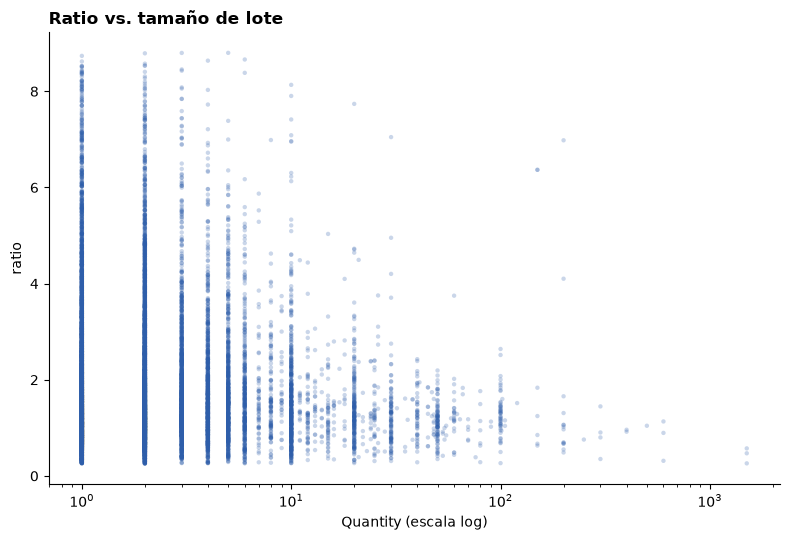

In [203]:
pearson_r, pearson_p = stats.pearsonr(df_entrenamiento["Quantity"], df_entrenamiento["ratio"])
spearman_r, spearman_p = stats.spearmanr(df_entrenamiento["Quantity"], df_entrenamiento["ratio"])

print("=" * 70)
print("RATIO vs CANTIDAD (tamaño de lote)")
print("=" * 70)
print(f"Correlación de Pearson:  r = {pearson_r:.4f}  (p = {pearson_p:.4g})")
print(f"Correlación de Spearman: r = {spearman_r:.4f}  (p = {spearman_p:.4g})")
print()
print(df_entrenamiento["Quantity"].describe().round(2))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.scatter(df_entrenamiento["Quantity"], df_entrenamiento["ratio"], s=10, alpha=0.25, color=BLUE, edgecolor='none')
ax.set_xscale("log")
ax.set_xlabel("Quantity (escala log)")
ax.set_ylabel("ratio")
ax.set_title("Ratio vs. tamaño de lote", fontsize=12, fontweight='bold', loc='left')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("res/procesed/graficos/ratio_vs_quantity.png", dpi=200, bbox_inches='tight')
plt.show()

> El eje de cantidades se representa en escala logarítmica por motivos puramente de visualización. La variable Quantity presenta una distribución muy sesgada (mediana de 2 unidades, percentil 90 en 9, frente a un máximo de 1.500), por lo que en escala lineal la mayoría de los puntos quedarían comprimidos junto al origen, dificultando apreciar el comportamiento del ratio en los lotes pequeños, donde se concentra la mayor parte de los datos. La escala logarítmica distribuye el rango de valores de forma más homogénea, permitiendo observar la relación tanto en lotes pequeños como grandes. Esta transformación afecta únicamente a la representación gráfica: los coeficientes de correlación se calculan sobre la variable original, sin transformar.

In [204]:
display(df_entrenamiento.sample(1))

,fecha_fase,IDMOTask,smOrdenId,smOrdenNme,smFaseNme,Description,IDUsualTask,MaquinaDominante,NombreMaquina,CodigoGrupo,NombreGrupo,smMaterialId,Descripción Artículo,CodProductLine,Nombre Línea,CodProductFamily,Nombre Família,ProductEntry,MaterialExit,Quantity,tiempo_real_efectivo,tiempo_previsto,ratio
10427,2025-09-24 11:13:32.703,4c79a022-7847-407d-a64a-9327a9e91d67,OF2508776,COPPER PART Arm MD639096S,CHO-PUN,Mecanitzar Punta al CH,987b3954-076b-4c65-9909-86c878839853,CM01,CHO MX60HB OKUMA,CH,Centros Mecanizado Horizontal Cobre,BR3XA3X0017,COPPER PART Arm MD639096S,B,Braços,BR,Braços rodons,0.0,0.0,1.0,32.4,73.0,0.443836


In [205]:
imputaciones_por_maquina = df_entrenamiento.groupby("MaquinaDominante").agg(
    n_fases=("IDMOTask", "count"),
).sort_values("n_fases", ascending=False)

print("=" * 70)
print("IMPUTACIONES MES POR MÁQUINA")
print("=" * 70)
print(imputaciones_por_maquina.round(2))
print("=" * 70)
print(f'Total de máquinas: {len(imputaciones_por_maquina)}')
print("=" * 70)

IMPUTACIONES MES POR MÁQUINA
                  n_fases
MaquinaDominante         
TN09                 3145
TP02                 3030
CM06                 1274
CM05                  884
TN04                  859
CM14                  682
CM16                  590
TN08                  543
TN10                  505
CM12                  431
TN05                  415
TP01                  379
CM08                  324
CM01                  210
FL01                  169
CM10                  148
TN07                  131
PH03                  127
PH04                  120
CM07                  110
CM15                   75
CM19                   36
CM17                   17
CM04                   16
CM11                    1
CM13                    1
CM18                    1
Total de máquinas: 27


La inspección del número de fases por máquina muestra un salto claro entre las máquinas con actividad habitual y un pequeño grupo con apenas registros: mientras la mayoría acumulan decenas o cientos de fases. Este hueco visible permite fijar un umbral de corte. Las máquinas por debajo de este umbral se agrupan en una categoría "Otras", conservando su familia de máquina (NombreGrupo) como variable, de forma que el modelo pueda seguir aprovechando esa información aunque no disponga de un patrón específico por máquina. Es la mejor opción para no descartar estos datos. De cara a un futuro práctico, a medida que estas maquinas registren más imputaciones se procederá darles su propia categoria de maquina y no la de "Otras".

In [206]:
conteo_maquina = df_entrenamiento["MaquinaDominante"].value_counts()
maquinas_raras = conteo_maquina[conteo_maquina < 30].index

print(f"Máquinas agrupadas en 'Otras' ({len(maquinas_raras)}): {list(maquinas_raras)}")

df_entrenamiento["MaquinaDominante"] = df_entrenamiento["MaquinaDominante"].where(
    ~df_entrenamiento["MaquinaDominante"].isin(maquinas_raras), "Otras"
)

print(df_entrenamiento["MaquinaDominante"].value_counts())

Máquinas agrupadas en 'Otras' (5): ['CM17', 'CM04', 'CM13', 'CM11', 'CM18']
MaquinaDominante
TN09     3145
TP02     3030
CM06     1274
CM05      884
TN04      859
CM14      682
CM16      590
TN08      543
TN10      505
CM12      431
TN05      415
TP01      379
CM08      324
CM01      210
FL01      169
CM10      148
TN07      131
PH03      127
PH04      120
CM07      110
CM15       75
CM19       36
Otras      36
Name: count, dtype: int64


In [207]:
maquinas_por_familia = df_entrenamiento.groupby("CodigoGrupo").agg(
    n_maquinas=("MaquinaDominante", "nunique"),
).sort_values("n_maquinas", ascending=False)

print("=" * 70)
print("MÁQUINAS POR FAMÍLIAS")
print("=" * 70)
print(maquinas_por_familia.round(2))
print("=" * 70)
print(f'Total de máquinas: {maquinas_por_familia["n_maquinas"].sum()}')
print("=" * 70)

MÁQUINAS POR FAMÍLIAS
             n_maquinas
CodigoGrupo            
CV                    4
TCN                   4
C5                    3
CV-ALU                3
CH                    3
CON                   2
FLEX                  2
MTP                   2
TPU                   2
Total de máquinas: 25


Tipos de fases

In [208]:
tipos_fases = df_entrenamiento.groupby("smFaseNme").agg(
    n_fases=("IDMOTask", "nunique"),
).sort_values("n_fases", ascending=False)

print("=" * 70)
print("TIPOS DE FASES")
print("=" * 70)
print(tipos_fases.round(2))
print("=" * 70)
print(f'Tipos de fases: {len(tipos_fases)}')
print("=" * 70)

TIPOS DE FASES
            n_fases
smFaseNme          
MTP            3355
TPP            1944
PE01           1843
DES            1615
TPG-CNY         780
TMO             679
CHO-PUN         661
TCN             526
CV-BAL          391
CV-BX           310
CH8             290
CON             279
MEC03           266
MEC01           255
PE02            238
FLX             171
MEC02            89
CV-ALU           72
PE03             66
CV-FL            57
MTP-ALU          51
CV-FC            46
CHO-CNYPUN       44
TPG-CON          34
CHO              30
CVCGEATEFL       26
CH-BAL           21
CHO-PI           19
CV-TEFL          17
CV-TE            11
CV-CG             9
MEC04             8
CV-CGEA           5
CH-ALU            4
FU-EA             4
CV-CGTEFL         3
C5-AL             2
CVCGEATE          2
Tipos de fases: 38


In [209]:
print("=" * 60)
print("RECUENTO DE ENTIDADES (dataset final, tras el corte de outliers)")
print("=" * 60)
print(f"Órdenes de fabricación:   {df_entrenamiento['smOrdenId'].nunique():>8,}".replace(',', '.'))
print(f"Fases de fabricación:     {df_entrenamiento['IDMOTask'].nunique():>8,}".replace(',', '.'))
print(f"Artículos:                {df_entrenamiento['smMaterialId'].nunique():>8,}".replace(',', '.'))
print(f"Líneas de artículos:      {df_entrenamiento['Nombre Línea'].nunique():>8,}".replace(',', '.'))
print(f"Famílias de artículos:    {df_entrenamiento['Nombre Família'].nunique():>8,}".replace(',', '.'))
print(f"Famílias de máquinas:     {df_entrenamiento['CodigoGrupo'].nunique():>8,}".replace(',', '.'))
print(f"Total de máquinas:        {df_entrenamiento['MaquinaDominante'].nunique():>8,}".replace(',', '.'))

print("=" * 60)

RECUENTO DE ENTIDADES (dataset final, tras el corte de outliers)
Órdenes de fabricación:      6.386
Fases de fabricación:       14.223
Artículos:                   3.889
Líneas de artículos:            17
Famílias de artículos:          44
Famílias de máquinas:            9
Total de máquinas:              23


# Analizar los ratios elevados

In [ ]:
t = df.copy()          # ← el dataframe del notebook 8 (ya con el corte IQR aplicado)

umbral_cola = t["ratio"].quantile(0.90)                           # el 10 % de ratios más altos = "la cola"
t["grupo_duracion"] = pd.qcut(t["tiempo_previsto"], q=5)          # 5 grupos por tiempo teórico
t["desv_minutos"] = t["tiempo_real_efectivo"] - t["tiempo_previsto"]

resumen = t.groupby("grupo_duracion", observed=True).agg(
    n=("ratio", "size"),
    mediana_ratio=("ratio", "median"),
    pct_en_cola=("ratio", lambda r: (r > umbral_cola).mean() * 100),
    mediana_desv_min=("desv_minutos", "median"),
).round(2)

print(f"Umbral de la cola (percentil 90 del ratio): {umbral_cola:.2f}\n")
print(resumen)

In [210]:
df_entrenamiento.to_parquet("res//procesed/df_entrenamiento.parquet")